In [1]:
import jax
import jax.numpy as jnp

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns  

import liesel.model as lsl
import liesel.goose as gs

from tensorflow_probability.substrates.jax.experimental import distributions as tfde
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.distributions as tfd
import tensorflow_probability.substrates.jax.bijectors as tfb

In [2]:
# Factory Functions to handle validate_args consistently

def make_wishart(df, scale_tril):
    """Factory that keeps validate_args strictly as a Python constant."""
    return tfd.WishartTriL(
        df=df, 
        scale_tril=scale_tril, 
        input_output_cholesky=True, 
        validate_args=False
    )

def make_mvn_precision(loc, precision_factor):
    """Factory for Precision-based MVN."""
    return tfde.MultivariateNormalPrecisionFactorLinearOperator(
        loc=loc,
        precision_factor=tf.linalg.LinearOperatorLowerTriangular(precision_factor),
        validate_args=False
    )

In [3]:
# Data Simulation

def simulate_data(seed=42):
    key = jax.random.PRNGKey(seed)
    k1, k2, k3 = jax.random.split(key, 3)
    
    n_units, n_obs_small, n_obs_large, n_alts, n_params = 100, 5, 50, 5, 5 
    counts = jnp.array([n_obs_small] * 50 + [n_obs_large] * 50)
    unit_idx = jnp.repeat(jnp.arange(n_units), counts)
    
    true_mu = jnp.array([1.0, -1.0, 0.0, 0.0, -3.0])
    true_Sigma = 3.0 * jnp.eye(n_params)
    true_Sigma = true_Sigma.at[3, 4].set(1.5)
    true_Sigma = true_Sigma.at[4, 3].set(1.5)
    
    beta_dist = tfd.MultivariateNormalFullCovariance(loc=true_mu, covariance_matrix=true_Sigma)
    betas = beta_dist.sample(seed=k1, sample_shape=(n_units,))
    
    X_list, y_list = [], []
    for i in range(n_units):
        n_i, beta_i = counts[i], betas[i]
        k2, sk = jax.random.split(k2)
        price = jax.random.uniform(sk, shape=(n_i, n_alts), minval=-1.5, maxval=0.0)
        
        D = jnp.zeros((n_i, n_alts, n_params))
        for a in range(4): D = D.at[:, a, a].set(1.0)
        D = D.at[:, :, 4].set(price)
        
        logits = jnp.einsum('ijk,k->ij', D, beta_i)
        k3, sk = jax.random.split(k3)
        choices = tfd.Categorical(logits=logits).sample(seed=sk)
        
        X_list.append(D)
        y_list.append(choices)
        
    return {
        "X": jnp.concatenate(X_list, axis=0),
        "y": jnp.concatenate(y_list, axis=0),
        "betas": betas,
        "unit_idx": unit_idx,
        "true_mu": true_mu,
        "true_Sigma": true_Sigma
    }

# Simulate Data for 100 decision makers
data = simulate_data()
k_dim = 5
n_units = 100

In [4]:
# Model Building

# Constants (Raw values to prevent tracer issues during setup)
nu_val = float(k_dim + 3)
V_inv_val = jnp.linalg.inv(nu_val * jnp.eye(k_dim))
Vinv_chol_val = jnp.linalg.cholesky(V_inv_val)
A_val = 0.01
zero_loc_val = jnp.zeros(k_dim)

# 1. Precision Matrix Cholesky Factor
# We use the factory function here
sigma_inv_chol = lsl.Var.new_param(
    value=jnp.eye(k_dim),
    distribution=lsl.Dist(make_wishart, df=nu_val, scale_tril=Vinv_chol_val),
    name="sigma_inv_chol"
)

# 2. Transformation
# Liesel will now re-run 'make_wishart' internally without hitting tracer errors
sigma_inv_chol_latent = sigma_inv_chol.transform(
    tfb.FillScaleTriL(diag_bijector=tfb.Exp()), 
    name="sigma_inv_chol_latent"
)

# 3. Population Mean (mu)
mu_prec_factor = lsl.Var.new_calc(
    lambda L: jnp.sqrt(A_val) * L, 
    L=sigma_inv_chol, 
    name="mu_prec_factor"
)

mu = lsl.Var.new_param(
    value=jnp.zeros(k_dim),
    distribution=lsl.Dist(make_mvn_precision, loc=zero_loc_val, precision_factor=mu_prec_factor),
    name="mu"
)

# 4. Unit-Level Parameters (beta_i)
beta_i = lsl.Var.new_param(
    value=jnp.zeros((n_units, k_dim)),
    distribution=lsl.Dist(make_mvn_precision, loc=mu, precision_factor=sigma_inv_chol),
    name="beta_i"
)

# Likelihood

X_var = lsl.Var.new_obs(data["X"], name="X_obs")
idx_var = lsl.Var.new_obs(data["unit_idx"], name="idx_obs")

# Expanded beta: mapping unit-betas to the observations
beta_expanded = lsl.Var.new_calc(
    lambda b, idx: b[idx], 
    b=beta_i, 
    idx=idx_var, 
    name="beta_expanded"
)

# Utility/Logits calculation
logits = lsl.Var.new_calc(
    lambda x, b: jnp.einsum("nij,nj->ni", x, b), 
    x=X_var, 
    b=beta_expanded, 
    name="logits"
)

# Final Likelihood
y_var = lsl.Var.new_obs(
    data["y"], 
    distribution=lsl.Dist(tfd.Categorical, logits=logits), 
    name="y"
)

In [5]:
# Model Assembly
model = lsl.Model([y_var])

eb = gs.EngineBuilder(seed=123, num_chains=4)
eb.set_model(gs.LieselInterface(model))
eb.set_initial_values(model.state)

# Kernels
eb.add_kernel(gs.NUTSKernel(["mu"]))
eb.add_kernel(gs.NUTSKernel(["sigma_inv_chol_latent"], mm_diag=False)) # mm diag tunes on full mass matrix instead of only diagonal matrix
eb.add_kernel(gs.NUTSKernel(["beta_i"]))

eb.set_duration(warmup_duration=2000, posterior_duration=10000)

engine = eb.build()
engine.sample_all_epochs()

c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\.venv\Lib\site-packages\jax\_src\numpy\array_methods.py:122: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...
liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 25 jitted together
100%|██████████████████████████████████████████| 3/3 [00:17<00:00,  5.91s/chunk]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 2, 1, 4, 5 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for ke

# Model Diagnostics

In [6]:
# Extract Results
results = engine.get_results()
samples = results.get_posterior_samples()

# Create summary for numerical diagnostics 
summary = gs.Summary(results)
# display(summary)
# (R-hat < 1.05 indicates convergence)

## Covariance Matrix

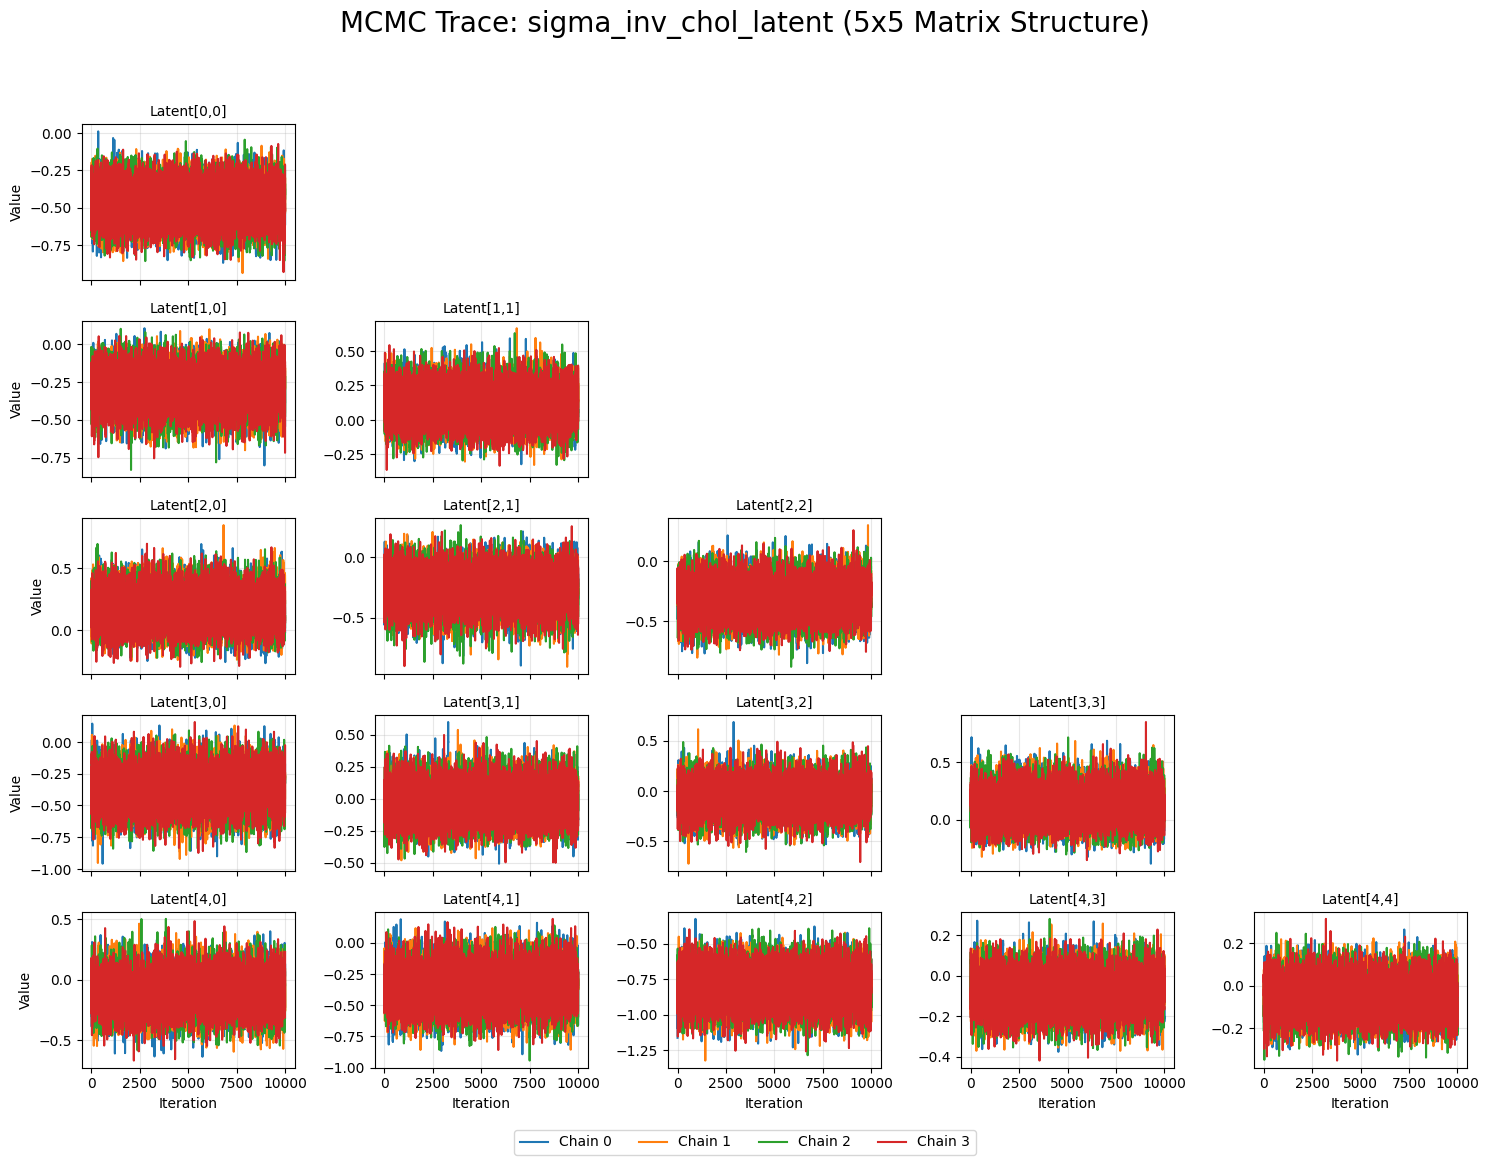

In [7]:
# Get the latent samples
# Shape: (chains, draws, 15)
latent_samples = results.get_posterior_samples()["sigma_inv_chol_latent"]
n_chains, n_draws, n_latent = latent_samples.shape

# Setup a 5x5 grid
fig, axes = plt.subplots(5, 5, figsize=(15, 12), sharex=True, sharey=False)

# Counter to keep track of which of the 15 parameters we are plotting
latent_idx = 0

for i in range(5):        # Rows
    for j in range(5):    # Columns
        ax = axes[i, j]
        
        # In a 5x5 lower triangular matrix, parameters exist only where i >= j
        if i >= j and latent_idx < n_latent:
            for chain in range(n_chains):
                ax.plot(latent_samples[chain, :, latent_idx], alpha=1, label=f"Chain {chain}")
            
            ax.set_title(f"Latent[{i},{j}]", fontsize=10)
            latent_idx += 1
        else:
            # Hide axes for the upper triangle where there is no data
            ax.axis('off')
        
        # Grid and formatting
        ax.grid(True, alpha=0.3)
        if i == 4:
            ax.set_xlabel("Iteration")
        if j == 0:
            ax.set_ylabel("Value")

# Add a single legend for the whole figure
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=n_chains, bbox_to_anchor=(0.5, 0.02))

plt.suptitle("MCMC Trace: sigma_inv_chol_latent (5x5 Matrix Structure)", fontsize=20)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

In [8]:
# Setup the bijector (must match the one in the model)
bijector = tfb.FillScaleTriL(diag_bijector=tfb.Exp())

# Function to turn 1D vector -> 5x5 Matrix -> Covariance Matrix
def latent_to_sigma(latent_vec):
    # Map 15-dim vector to 5x5 Lower Triangular Matrix (L)
    L = bijector.forward(latent_vec)

    # Compute Precision (Omega = L @ L.T)
    # Invert to get Covariance (Sigma = inv(Omega))
    # This is equivalent to inv(L.T) @ inv(L) which is more stable
    precision_mat = L @ L.T
    return jnp.linalg.inv(precision_mat)

# Vectorize across chains and draws
v_latent_to_sigma = jax.vmap(jax.vmap(latent_to_sigma))
sigma_samples = v_latent_to_sigma(latent_samples)

# Quick comparison of true values and posterior mean
sigma_posterior_mean = jnp.mean(sigma_samples, axis=(0, 1))

print("--- Comparison of Covariance Matrices ---")
print("\nTrue Sigma (Simulation):")
print(jnp.round(data["true_Sigma"], 3))

print("\nEstimated Sigma (Posterior Mean):")
print(jnp.round(sigma_posterior_mean, 3))

--- Comparison of Covariance Matrices ---

True Sigma (Simulation):
[[3.0000002 0.        0.        0.        0.       ]
 [0.        3.0000002 0.        0.        0.       ]
 [0.        0.        3.0000002 0.        0.       ]
 [0.        0.        0.        3.0000002 1.5000001]
 [0.        0.        0.        1.5000001 3.0000002]]

Estimated Sigma (Posterior Mean):
[[ 2.43        0.24800001  0.36900002 -0.041       0.57500005]
 [ 0.24800001  2.522       0.785      -0.02       -0.629     ]
 [ 0.36900002  0.785       5.5530005  -0.123      -0.614     ]
 [-0.041      -0.02       -0.123       2.624       1.051     ]
 [ 0.57500005 -0.629      -0.614       1.051       2.615     ]]


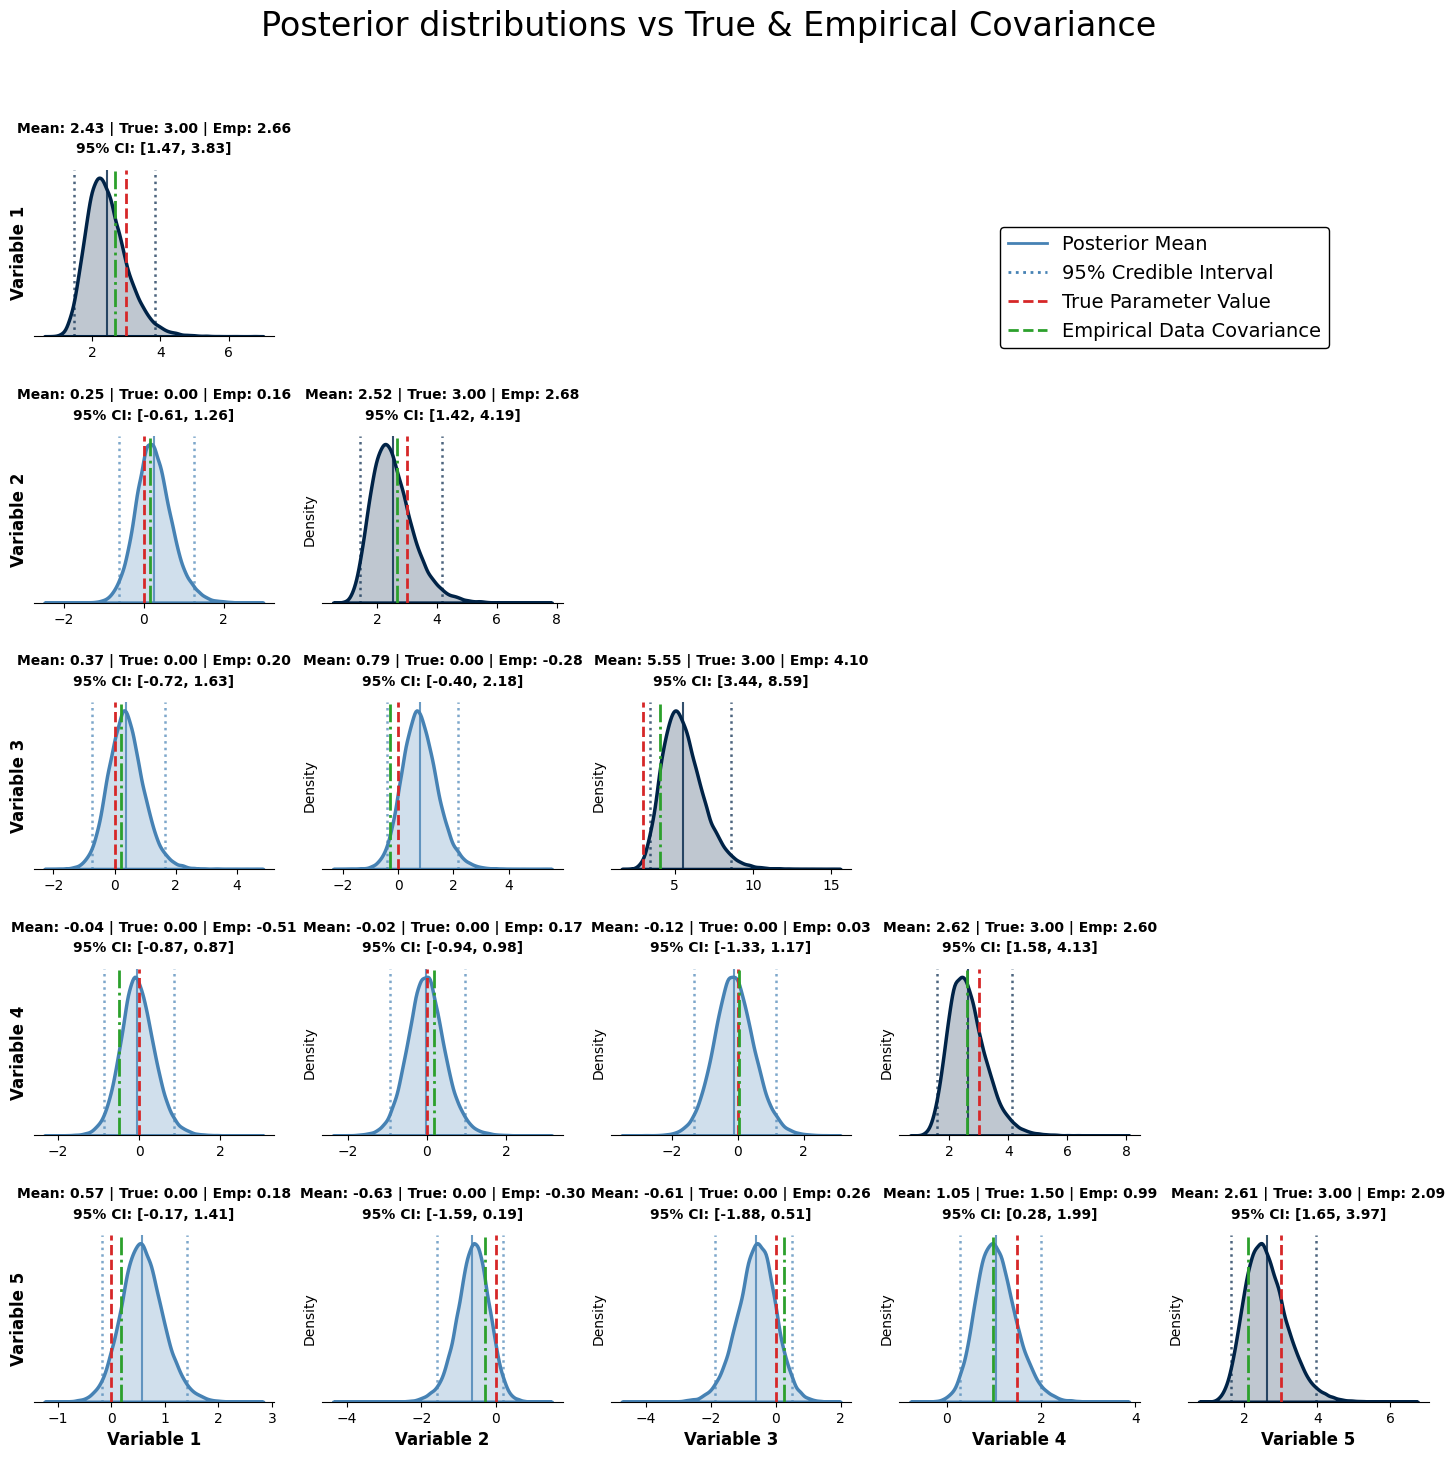

In [9]:
def plot_final_covariance_complete(samples, true_matrix=None, empirical_matrix=None):
    n_dim = samples.shape[-1]
    
    # Create the figure and axes
    fig, axes = plt.subplots(n_dim, n_dim, figsize=(18, 16))
    
    flattened_samples = samples.reshape(-1, n_dim, n_dim)
    
    # Color Palette
    diag_color      = "#002347"  
    off_diag_color  = "#4682B4"  
    true_val_color  = "#D62728"  
    emp_val_color   = "#2CA02C"  

    # Loop through the grid
    for i in range(n_dim):
        for j in range(n_dim):
            ax = axes[i, j]
            
            # Lower Triangular Logic
            if j > i:
                ax.axis('off') 
                continue
            
            data_vec = flattened_samples[:, i, j]
            is_diag = (i == j)
            current_color = diag_color if is_diag else off_diag_color
            
            # Stats Calculation
            post_mean = np.mean(data_vec)
            ci_low, ci_high = np.percentile(data_vec, [2.5, 97.5])
            
            # Plot KDE
            sns.kdeplot(data_vec, ax=ax, fill=True, color=current_color, alpha=0.25, lw=2.5)
            
            # Reference Lines
            ax.axvline(post_mean, color=current_color, linestyle="-", lw=1.5, alpha=0.8)
            ax.axvline(ci_low, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            ax.axvline(ci_high, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            
            title_parts = [f"Mean: {post_mean:.2f}"]
            
            if true_matrix is not None:
                true_val = true_matrix[i, j]
                ax.axvline(true_val, color=true_val_color, linestyle="--", lw=2)
                title_parts.append(f"True: {true_val:.2f}")
            
            if empirical_matrix is not None:
                emp_val = empirical_matrix[i, j]
                ax.axvline(emp_val, color=emp_val_color, linestyle="-.", lw=2)
                title_parts.append(f"Emp: {emp_val:.2f}")

            # Textual Labels
            stats_str = " | ".join(title_parts)
            title_str = (
                f"{stats_str}\n"
                f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]"
            )
            ax.set_title(title_str, fontsize=10, pad=12, linespacing=1.6, fontweight='bold')

            # Aesthetic Polish
            ax.set_yticks([])
            sns.despine(ax=ax, left=True)
            
            if i == n_dim - 1:
                ax.set_xlabel(f"Variable {j+1}", fontsize=12, fontweight='bold')
            if j == 0:
                ax.set_ylabel(f"Variable {i+1}", fontsize=12, fontweight='bold')

    # --- NEW: FIGURE-LEVEL FLOATING LEGEND ---
    legend_elements = [
        Line2D([0], [0], color=off_diag_color, linestyle='-',  lw=2, label='Posterior Mean'),
        Line2D([0], [0], color=off_diag_color, linestyle=':',  lw=2, label='95% Credible Interval'),
        Line2D([0], [0], color=true_val_color, linestyle='--', lw=2, label='True Parameter Value'),
        Line2D([0], [0], color=emp_val_color,  linestyle='--', lw=2, label='Empirical Data Covariance')
    ]
    
    # We use fig.legend instead of ax.legend
    fig.legend(
        handles=legend_elements, 
        loc='upper right',           # Anchor point on the legend box
        bbox_to_anchor=(0.85, 0.85), # (x, y) coordinates for the anchor relative to the whole figure (0 to 1)
        fontsize=14, 
        frameon=True,         
        edgecolor='black',    
        framealpha=1,         
        fancybox=True         
    )

    plt.suptitle("Posterior distributions vs True & Empirical Covariance", 
                 fontsize=24, y=0.98, fontweight='light')
    
    plt.subplots_adjust(hspace=0.6, wspace=0.2)
    plt.show()

# Calculate the empirical covariance matrix
empirical_sigma = jnp.cov(data["betas"], rowvar=False)

# Run the plot
plot_final_covariance_complete(sigma_samples, data["true_Sigma"], empirical_sigma)

The estimation of the covariance matrix of the beta generating normal distribution seems to work well. The credible intervals of all parameters always cover the empirical parameter values. With one exception this is also the case for the true value of the cavariance matrix of the data beta generating function.

## Convergence Diagnostics

In [10]:
def plot_detailed_param(results_dict, param_name, param_indices):
    """
    Plot detailed diagnostics for a parameter.
    param_indices can be a single int or list of ints.
    """
    if isinstance(param_indices, int):
        param_indices = [param_indices]
    for idx in param_indices:
        print(f"Detailed Diagnostics: {param_name}[{idx}]")
        gs.plot_param(results_dict, param_name, param_index=idx)
        plt.show()


 Global Mu Trace Plots


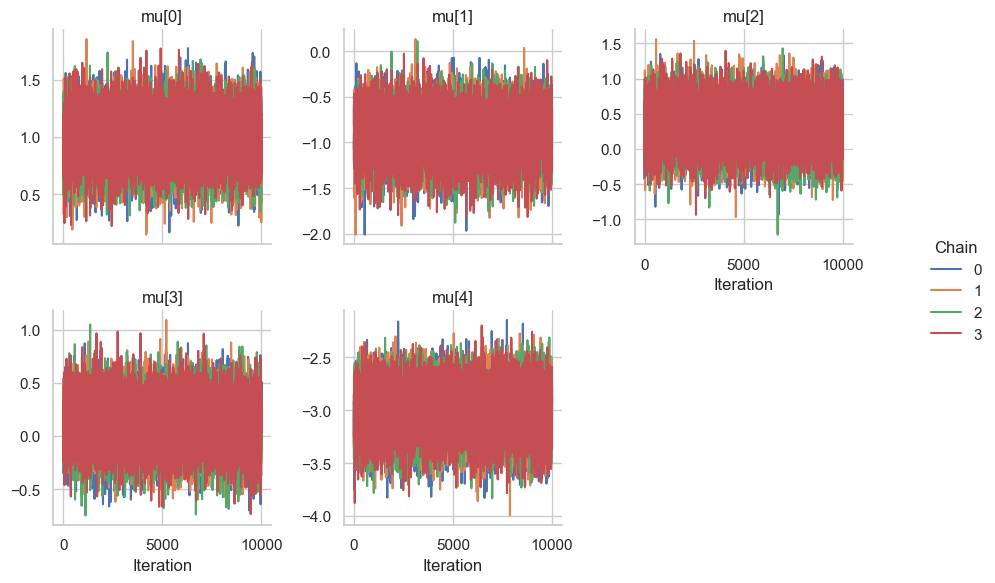


Detailed Mu Parameter Diagnostics
Detailed Diagnostics: mu[0]


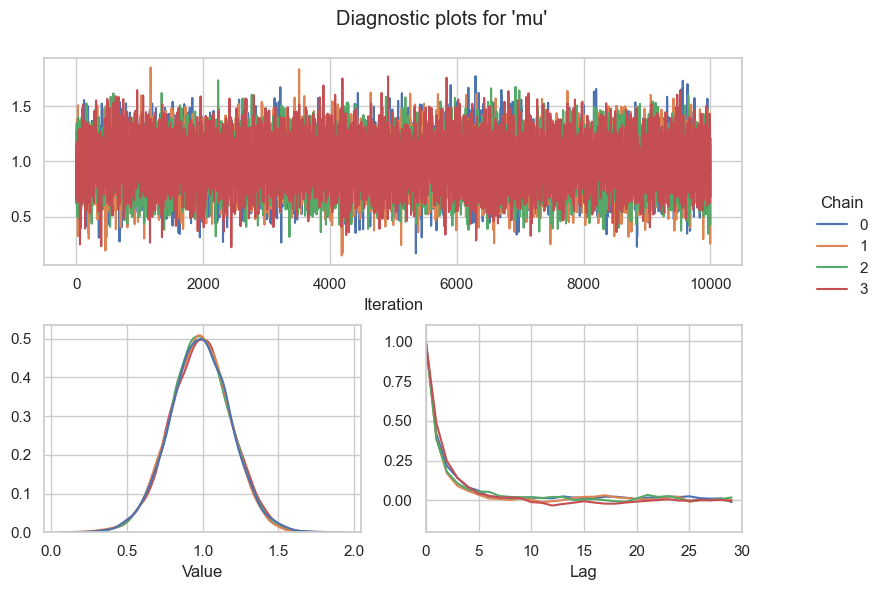

Detailed Diagnostics: mu[1]


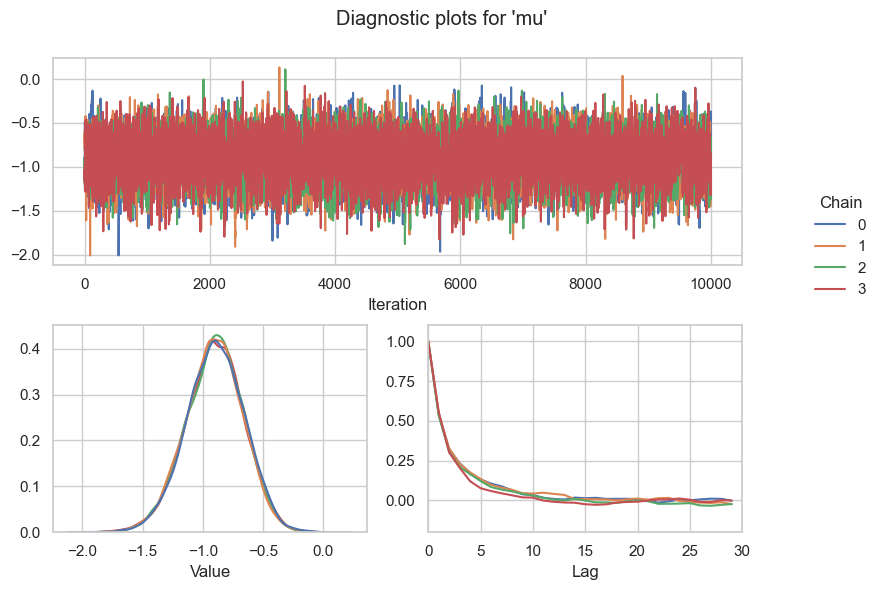

Detailed Diagnostics: mu[2]


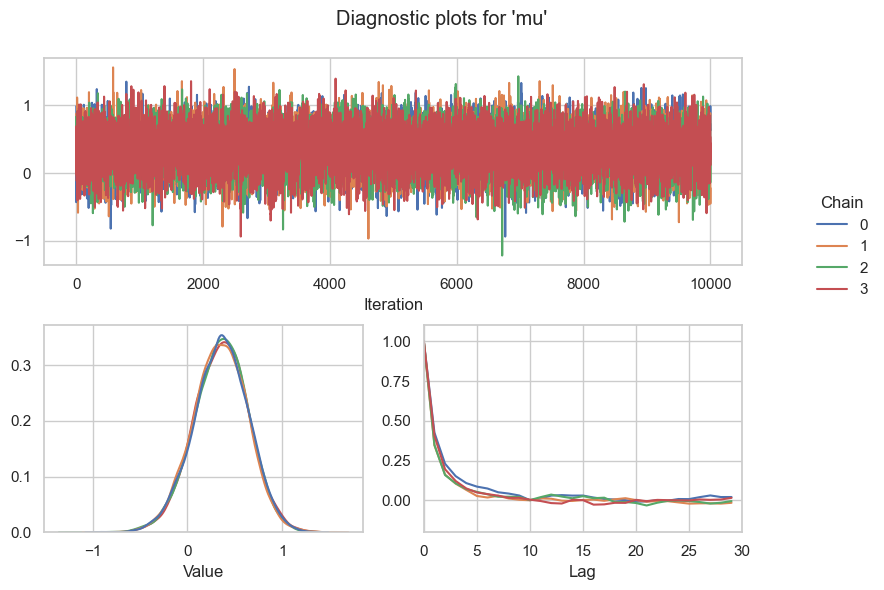

Detailed Diagnostics: mu[3]


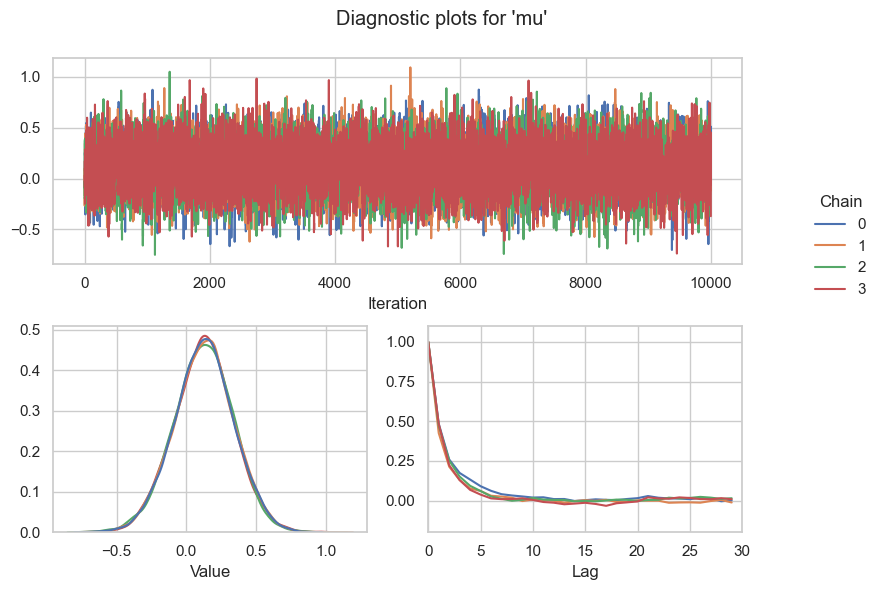

Detailed Diagnostics: mu[4]


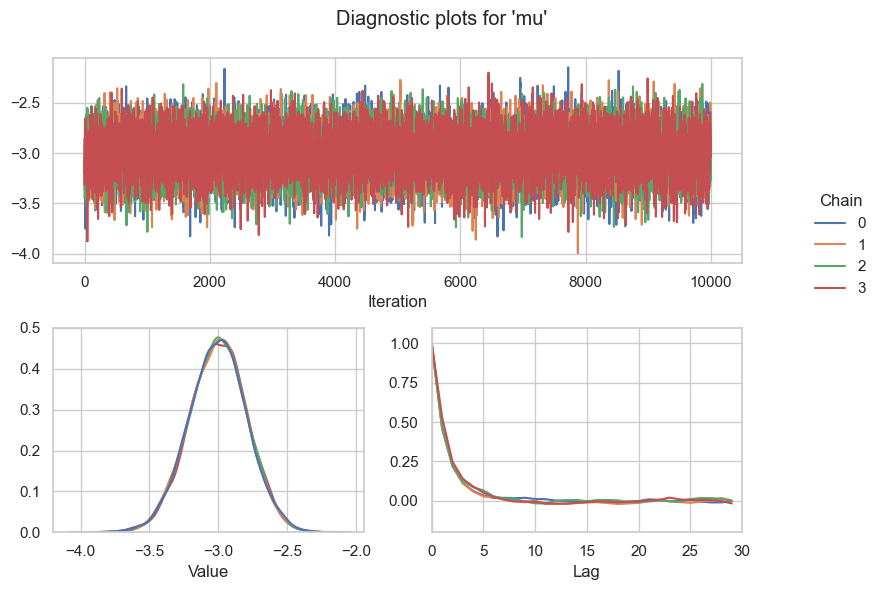

In [11]:
# =======================
# CONVERGENCE DIAGNOSTICS
# =======================

# Global mu Diagnostics
print("\n Global Mu Trace Plots")
gs.plot_trace(results, "mu")
plt.show()

print("\nDetailed Mu Parameter Diagnostics")
plot_detailed_param(results, "mu", param_indices=range(5))
plt.show()

In [12]:
# ===============================
# POSTERIOR SUMMARY STATISTICS
# ===============================

# Extract information about beta_i samples
chains, samples_num, n_units, n_params = samples["beta_i"].shape

# Beta_i Summary Statistics
print("\n Beta_i (Unit-Level Parameters) Summary")
beta_posterior_means = jnp.mean(samples["beta_i"], axis=(0, 1))  # (units, parameters)
beta_posterior_stds = jnp.std(samples["beta_i"], axis=(0, 1))    # (units, parameters)

print(f"Shape: {beta_posterior_means.shape} (units x parameters)")
print("\nPosterior Means:")
print(beta_posterior_means)
print("\nPosterior Std Dev:")
print(beta_posterior_stds)

# Mu Summary Statistics 
print("\n Mu (Global Parameters) Summary")
mu_posterior_means = jnp.mean(samples["mu"], axis=(0, 1))  # (units, params)
mu_posterior_stds = jnp.std(samples["mu"], axis=(0, 1))

print(f"Shape: {mu_posterior_means.shape}")
print("\nPosterior Means:")
print(mu_posterior_means)
print("\nSimluated Means:")
print([1,-1,0,0,-3])
print("\nPosterior Std Dev:")
print(mu_posterior_stds)


 Beta_i (Unit-Level Parameters) Summary
Shape: (100, 5) (units x parameters)

Posterior Means:
[[ 0.05589333 -1.310614    1.4401532  -0.57072496 -3.7201788 ]
 [ 0.6170908   0.39520726 -0.87163925 -1.4482363  -4.481141  ]
 [ 0.4794077  -0.54090846  1.6208991   0.526354   -3.6304655 ]
 [ 0.25861976 -0.96533346 -2.2047086  -1.2983602  -3.7743018 ]
 [-0.628913   -0.8762475  -1.8091252   1.3268416  -2.0726407 ]
 [ 1.5996608   0.17590573  0.16822346 -0.74518806 -3.6546304 ]
 [ 1.1825405  -0.08909211  1.7988212  -0.67360574 -3.478251  ]
 [ 2.420669   -1.4615003   0.52609825 -0.8775063  -2.5638278 ]
 [ 1.0497965  -1.3128167  -1.042876    2.295144   -2.1298766 ]
 [ 2.6738844  -1.5311236  -1.0229723   0.27035633 -1.9533184 ]
 [-0.18223234 -1.5954443  -1.3903302   2.872611   -1.7007252 ]
 [ 2.4031582  -1.3997658  -0.6283945   0.067769   -2.930687  ]
 [ 2.276185    0.9622292   0.52893263 -0.6697885  -2.6157248 ]
 [ 1.0208493  -1.3762721   2.817372    0.71443534 -1.9960015 ]
 [ 2.279894    0.35671

In [13]:
# ==================
# PARAMETER RECOVERY
# ==================

if "true_betas" in data:
    print("\nUnit-Level Parameter Recovery (All Parameters)")
    for param_idx in range(n_params):
        plt.figure(figsize=(8, 6))
        sns.scatterplot(
            x=data["true_betas"][:, param_idx],
            y=beta_posterior_means[:, param_idx],
            alpha=0.9,
            s=50
        )
        
        # Identity line
        min_val = min(data["true_betas"][:, param_idx].min(), 
                     beta_posterior_means[:, param_idx].min())
        max_val = max(data["true_betas"][:, param_idx].max(), 
                     beta_posterior_means[:, param_idx].max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', 
                linewidth=2, label="Perfect Recovery")
        
        plt.xlabel("True Beta")
        plt.ylabel("Posterior Mean")
        plt.title(f"Parameter Recovery: Beta Index {param_idx}")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    # Compute recovery quality
    print("\nRecovery Quality")
    for param_idx in range(n_params):
        true_vals = data["true_betas"][:, param_idx]
        est_vals = beta_posterior_means[:, param_idx]
        corr = np.corrcoef(true_vals, est_vals)[0, 1]
        print(f"Parameter {param_idx}, Correlation={corr:.4f}")


Boxplots (Posterior Ranges)


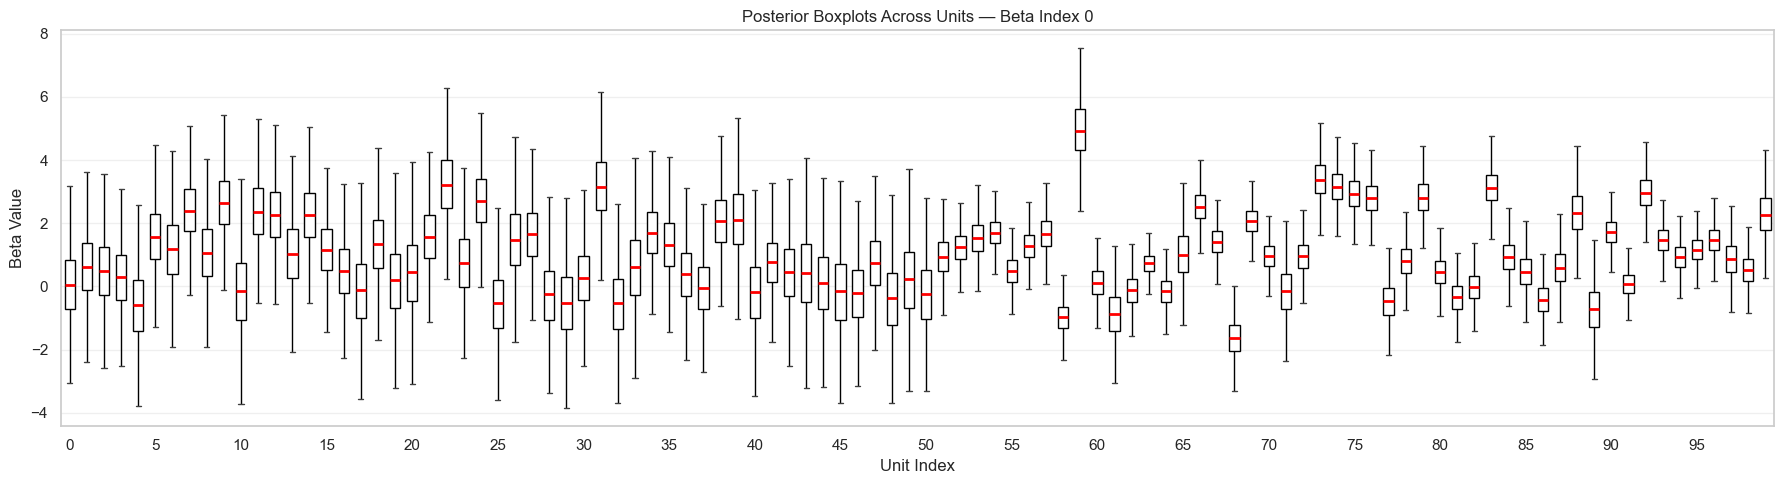

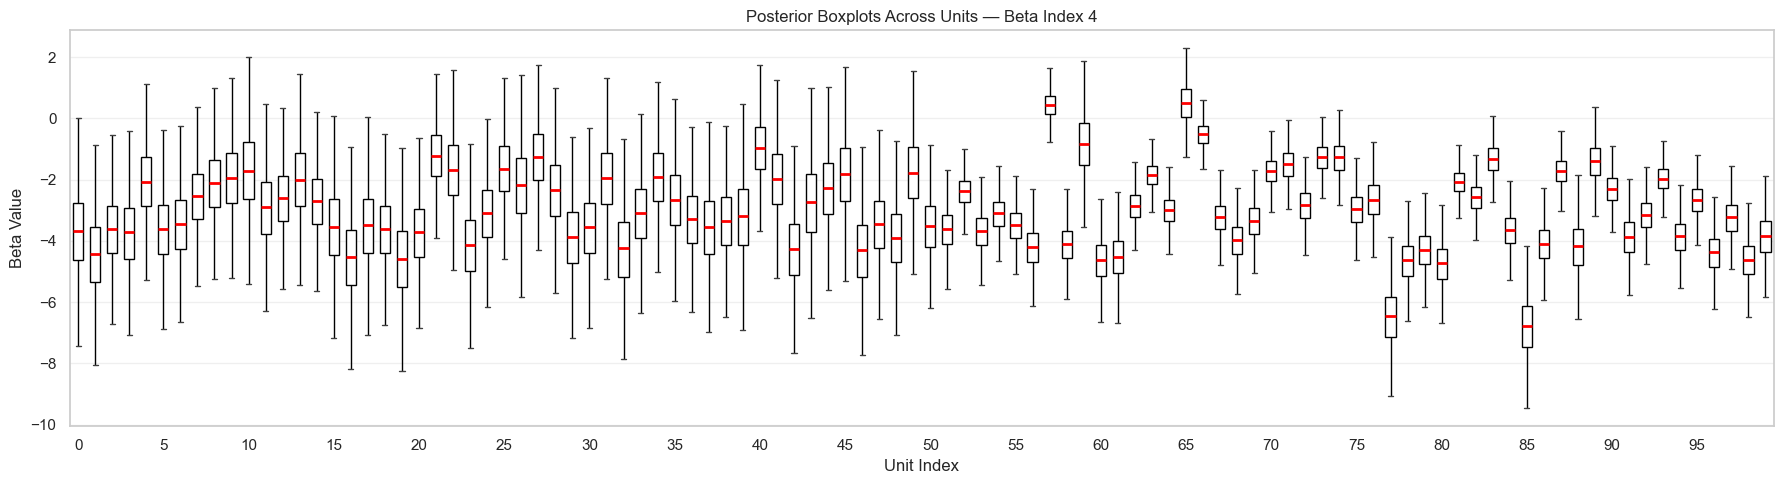


Faceted Posterior Distributions per Unit (Selected Parameters)


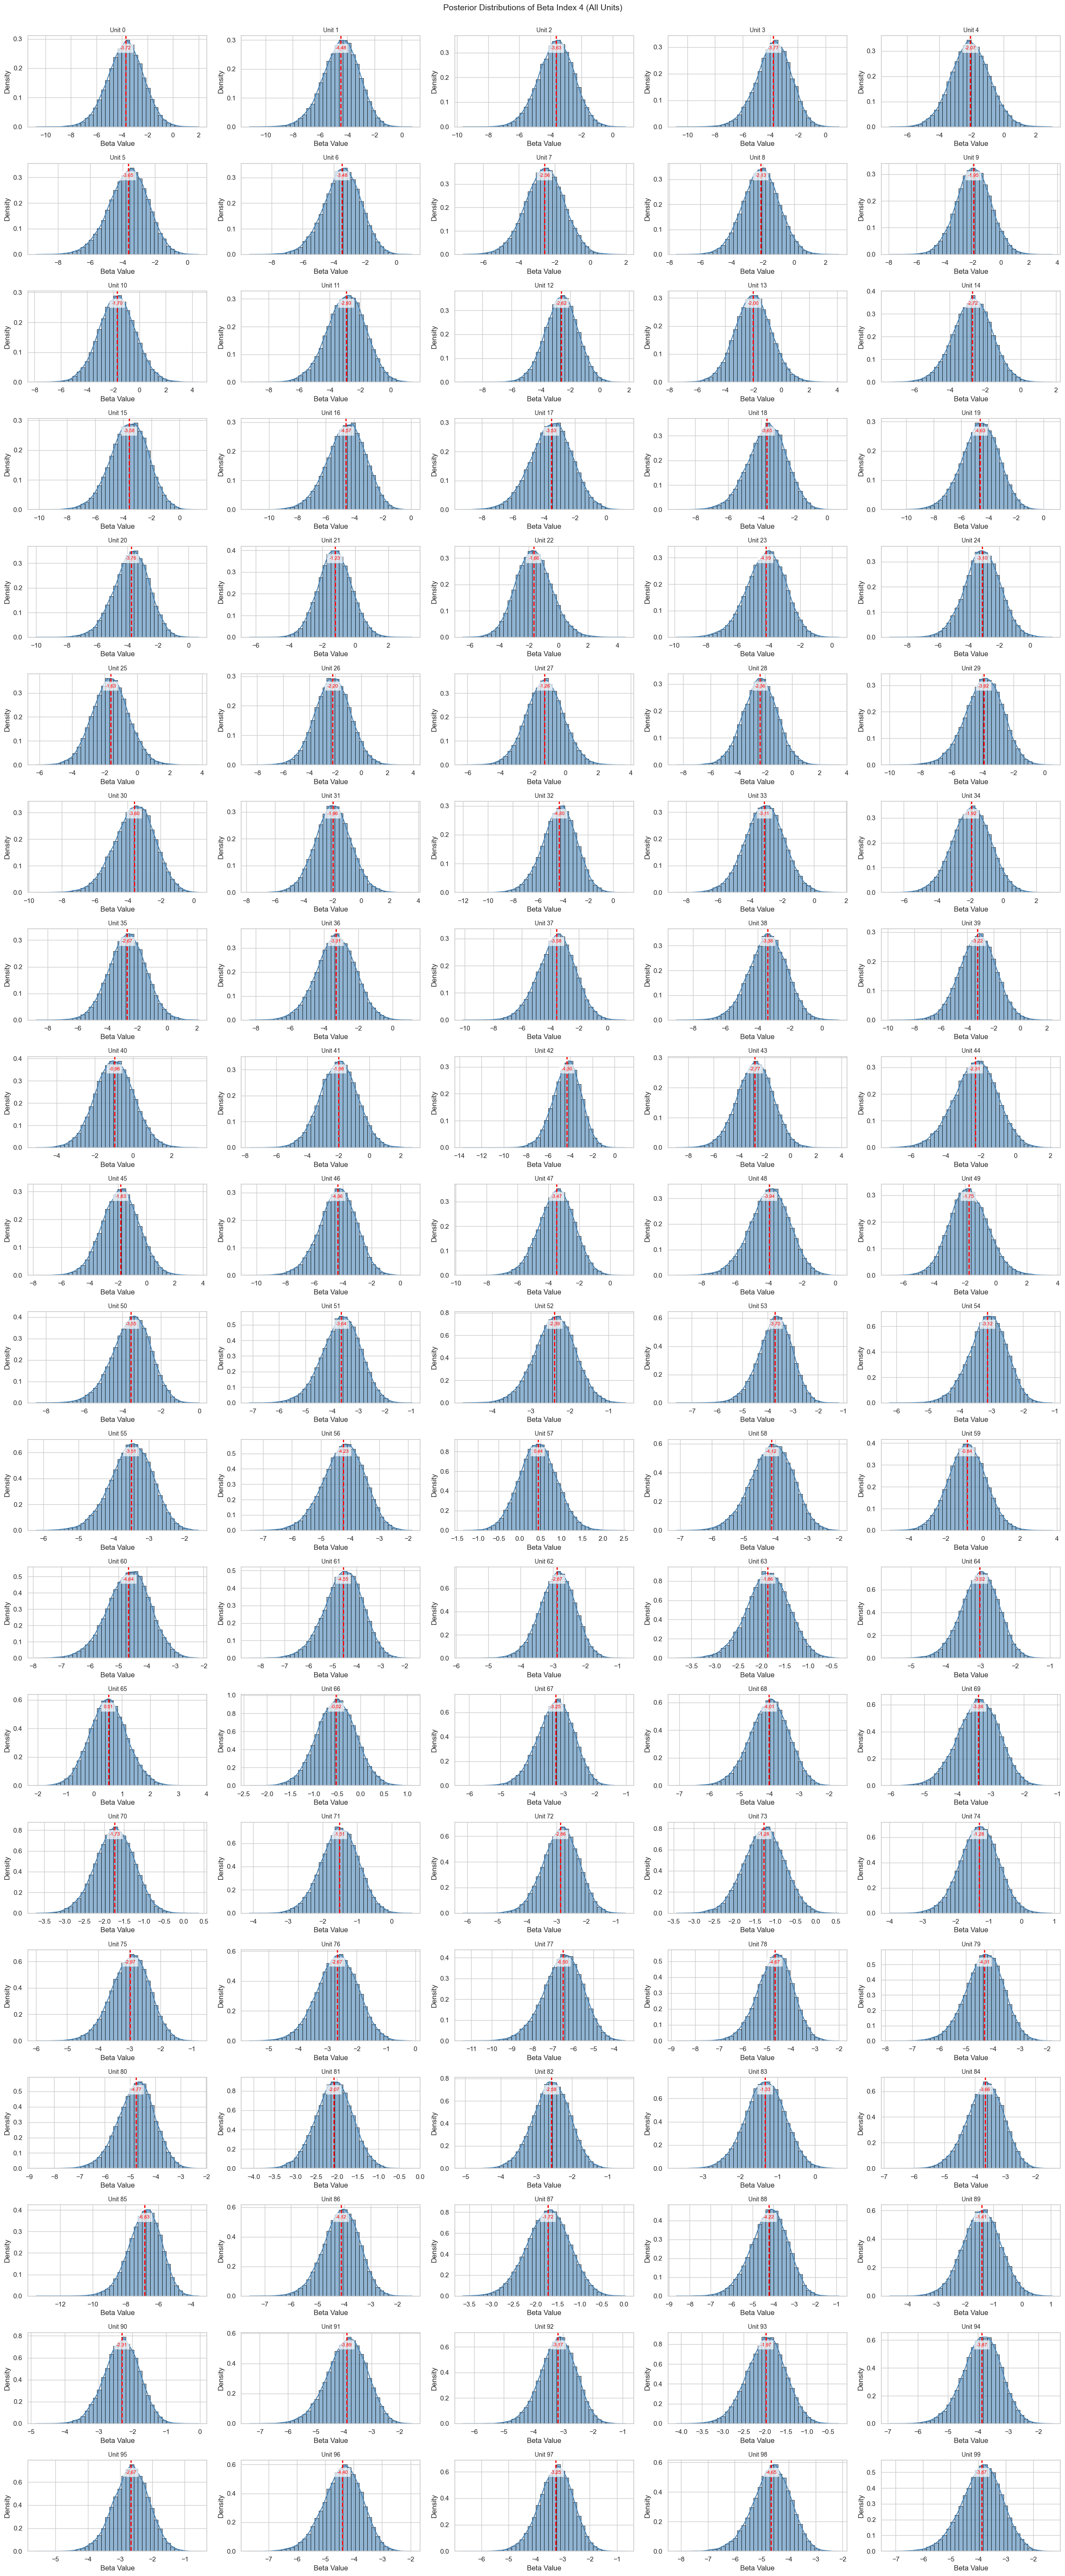

In [14]:
# =======================================
# UNIT-LEVEL BETA POSTERIOR DISTRIBUTIONS
# =======================================

# Boxplots
print("\nBoxplots (Posterior Ranges)")
def plot_unit_betas_boxplot(samples, params=None, figsize=(18, 5)):
    chains, n_samples, n_units, n_params_total = samples.shape
    if params is None:
        params = list(range(n_params_total))
    for param_idx in params:
        traces = samples[..., :, param_idx]
        traces_2d = traces.reshape(-1, n_units)
        
        plt.figure(figsize=figsize)
        sns.boxplot(
            data=traces_2d,
            color="white",
            showcaps=True,
            boxprops={'facecolor': 'white', 'edgecolor': 'black'},
            whiskerprops={'color': 'black'},
            medianprops={'color': 'red', 'linewidth': 2},
            showfliers=False,
            width=0.6
        )
        plt.xticks(range(0, n_units, 5))
        plt.title(f"Posterior Boxplots Across Units — Beta Index {param_idx}")
        plt.xlabel("Unit Index")
        plt.ylabel("Beta Value")
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

# Plot boxplots for individual betas for index 0 and 4
plot_unit_betas_boxplot(samples["beta_i"], params=[0, 4])  # Intercept and Price Slope

# Faceted histograms with KDE for parameter list (longer runtime)
print("\nFaceted Posterior Distributions per Unit (Selected Parameters)")
def plot_unit_beta_distributions(samples_dict, beta_index, bins=40):
    """
    Faceted histograms with KDE for all units, focusing on one beta index.
    """
    beta_samples = samples_dict["beta_i"]  # (chains, draws, units, betas)
    n_units = beta_samples.shape[2]
    
    # Flatten chains and draws to (units, posterior_samples)
    flat = beta_samples[..., :, beta_index].reshape(-1, n_units).T
    
    ncols = 5
    nrows = int(np.ceil(n_units / ncols))
    plt.figure(figsize=(5 * ncols, 3 * nrows))
    
    for unit in range(n_units):
        unit_samples = flat[unit]
        mean_val = np.mean(unit_samples)
        
        ax = plt.subplot(nrows, ncols, unit + 1)
        sns.histplot(unit_samples, bins=bins, kde=True, stat="density", 
                    alpha=0.6, color="steelblue", edgecolor="black")
        
        # Mean line
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2)
        ax.text(mean_val, ax.get_ylim()[1] * 0.85,
               f"{mean_val:.2f}", color="red", ha="center", fontsize=8,
               bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        
        ax.set_title(f"Unit {unit}", fontsize=10)
        ax.set_xlabel("Beta Value")
        ax.set_ylabel("Density")
    
    plt.suptitle(f"Posterior Distributions of Beta Index {beta_index} (All Units)",
                fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()

# Plot for key parameters
for param_idx in [4]:  # simply price slope
    plot_unit_beta_distributions(samples, param_idx)

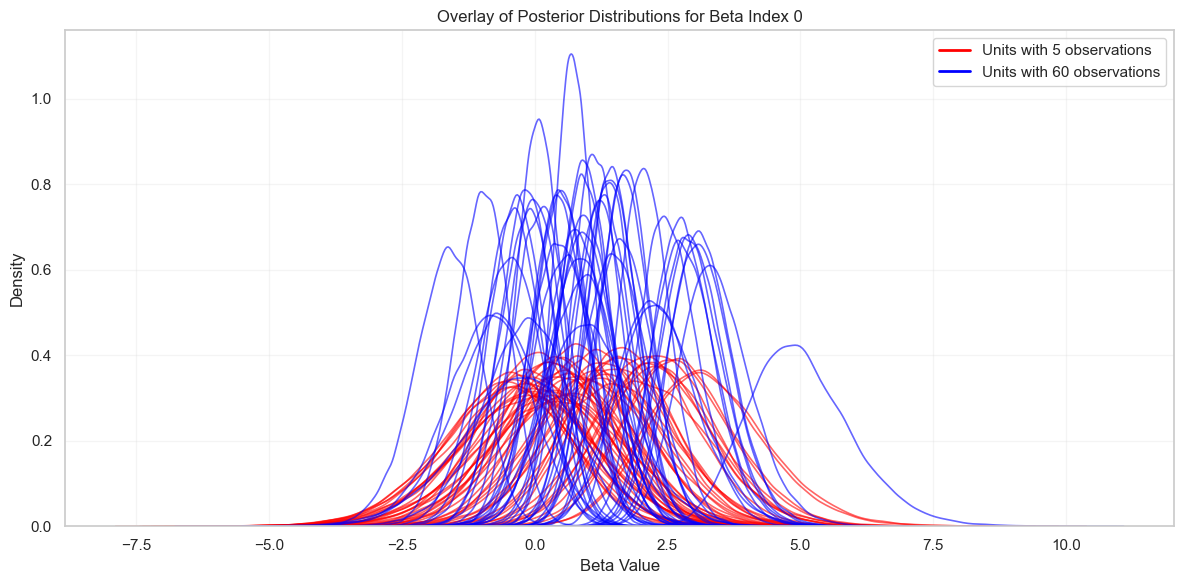

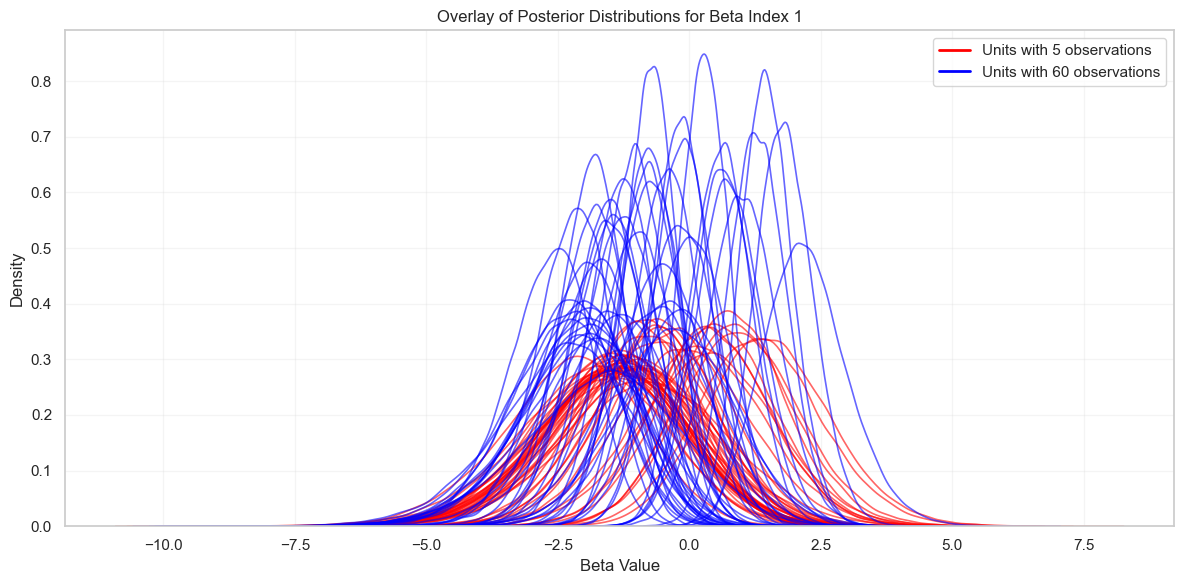

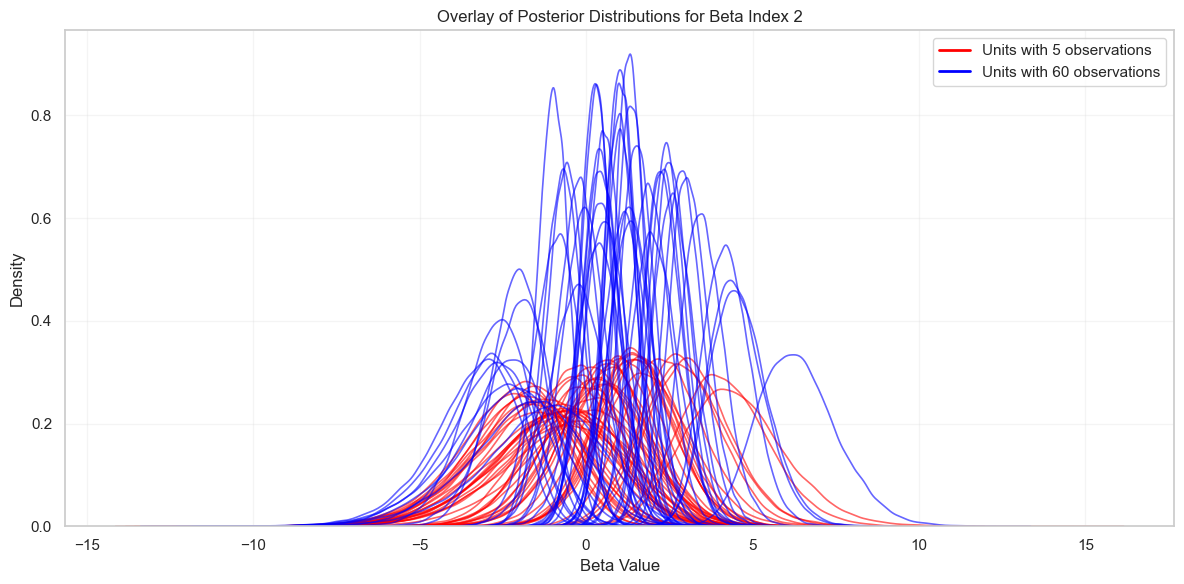

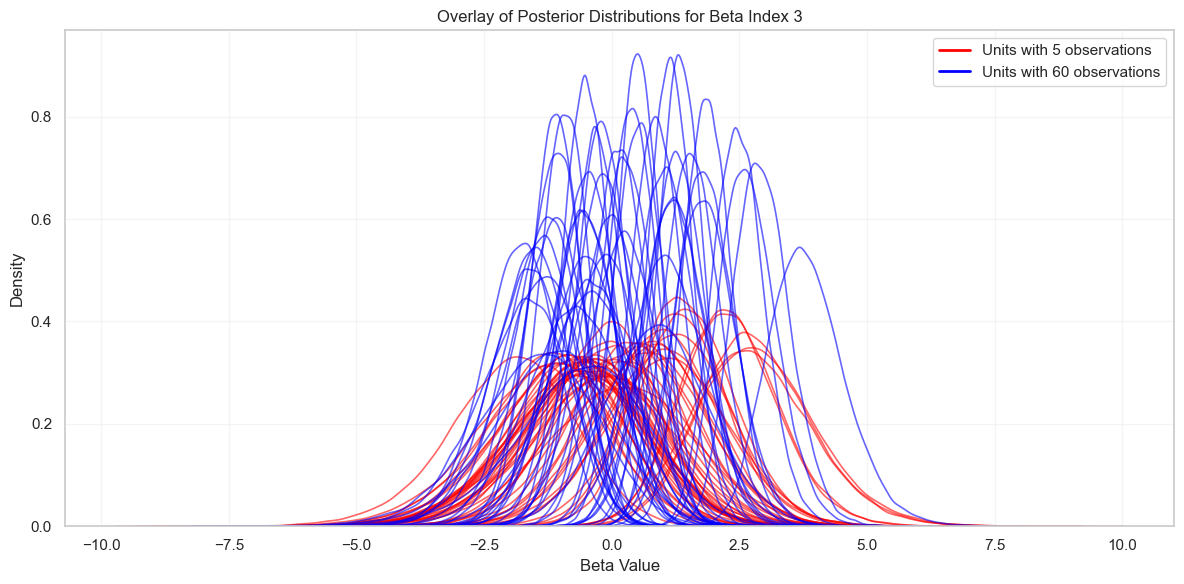

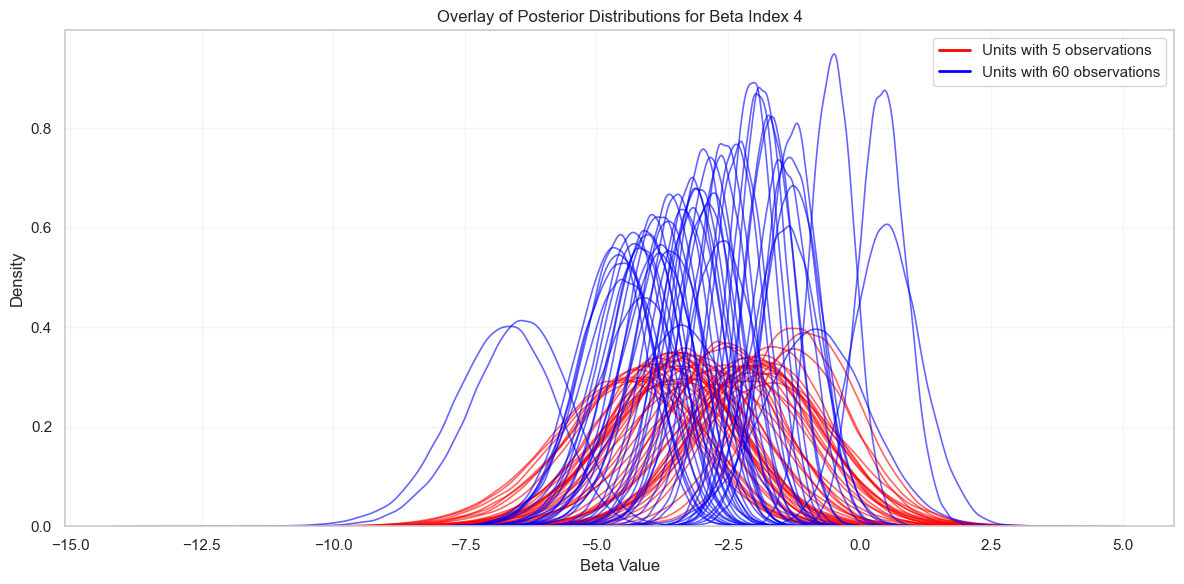

In [15]:
# ================================
# OVERLAID POSTERIOR DISTRIBUTIONS
# ================================

def plot_all_units_overlay(samples_dict, beta_index):
    """
    KDE overlay plot for all units, color-coded by data availability.
    """
    beta = samples_dict["beta_i"]  # (chains, draws, units, betas)
    n_units = beta.shape[2]
    
    # Flatten (chains * draws) for each unit
    flat = beta[..., :, beta_index].reshape(-1, n_units).T
    
    plt.figure(figsize=(12, 6))
    for unit in range(n_units):
        # Color by data availability (example: first 50 units = 5 obs, rest = 50 obs)
        color = "red" if unit < 50 else "blue"
        sns.kdeplot(flat[unit], linewidth=1.2, color=color, alpha=0.6)
    
    # Legend
    plt.plot([], [], color="red", linewidth=2, label="Units with 5 observations")
    plt.plot([], [], color="blue", linewidth=2, label="Units with 60 observations")
    plt.legend(fontsize=11)
    
    plt.title(f"Overlay of Posterior Distributions for Beta Index {beta_index}")
    plt.xlabel("Beta Value")
    plt.ylabel("Density")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

for param_idx in range(n_params):
    plot_all_units_overlay(samples, param_idx)

Mu posterior overlays for all parameters:


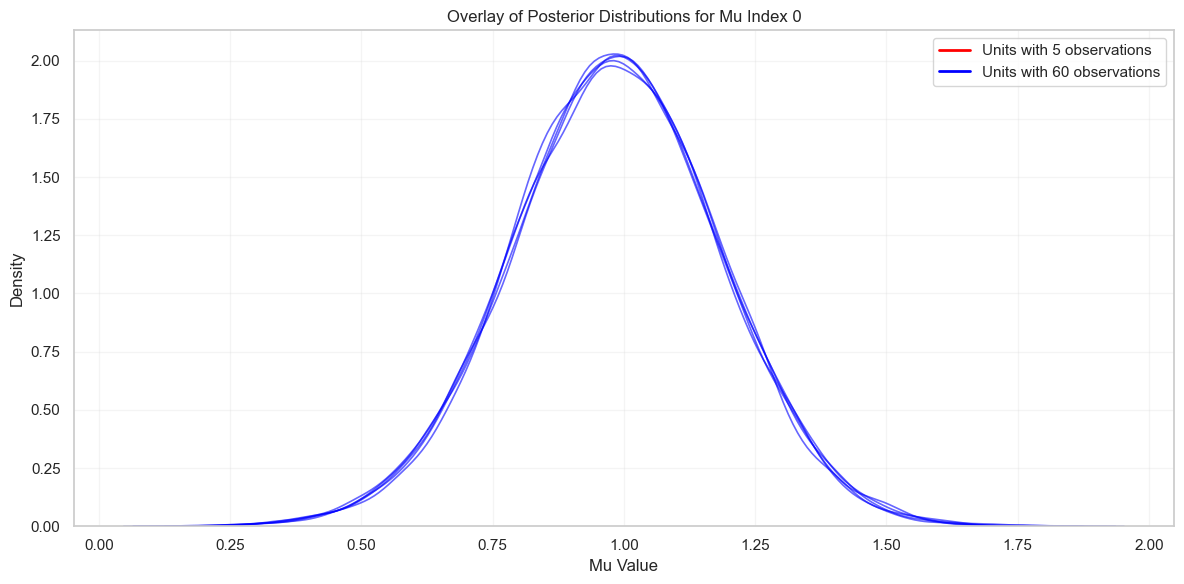

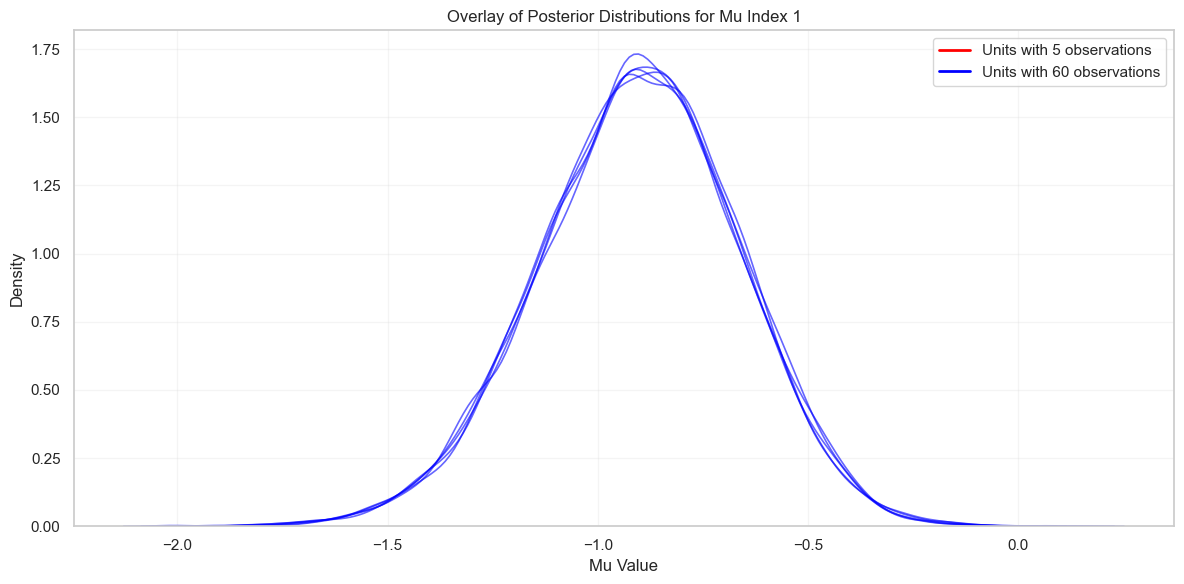

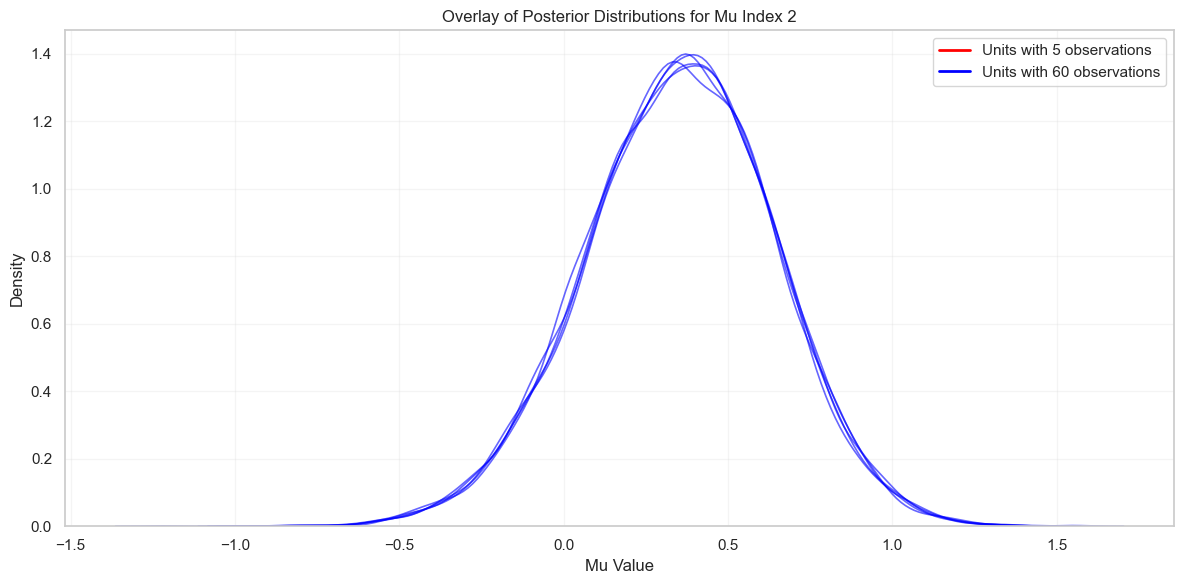

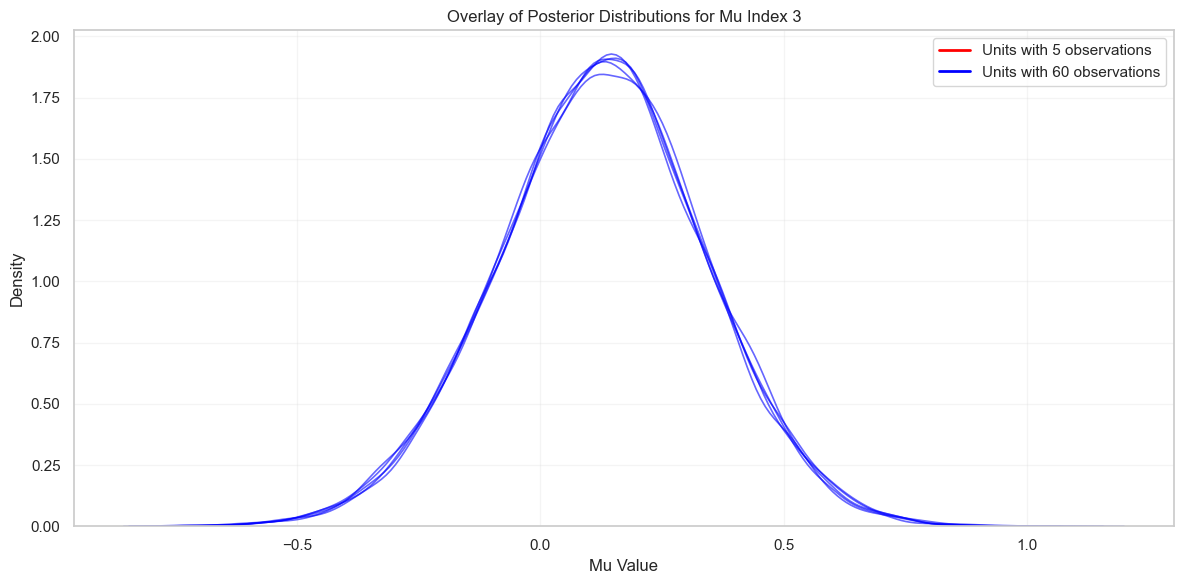

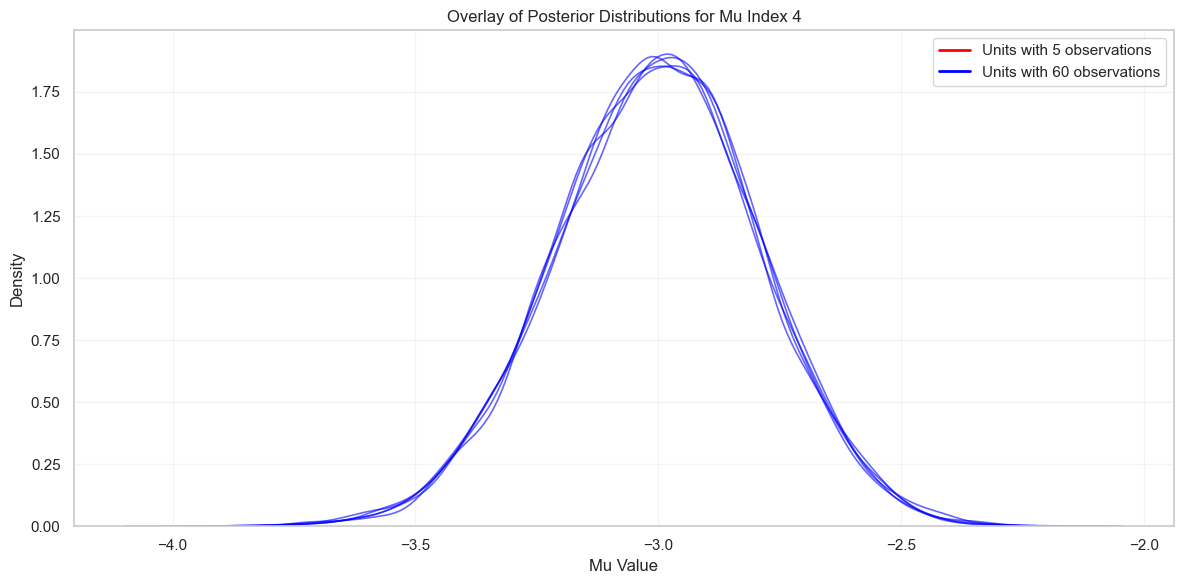

In [16]:
# =================================
# GLOBAL MU POSTERIOR DISTRIBUTIONS
# =================================

def plot_all_units_overlay_mu(samples_dict, mu_index):
    """
    KDE overlay for mu parameters across all units.
    """
    mu = samples_dict["mu"]  # (chains, draws, units, mus)
    n_units = mu.shape[2]
    
    flat = mu[..., :, mu_index].reshape(-1, n_units).T
    
    plt.figure(figsize=(12, 6))
    for unit in range(n_units):
        sns.kdeplot(flat[unit], linewidth=1.2, color="blue", alpha=0.6)
    
    plt.plot([], [], color="red", linewidth=2, label="Units with 5 observations")
    plt.plot([], [], color="blue", linewidth=2, label="Units with 60 observations")
    plt.legend(fontsize=11)
    
    plt.title(f"Overlay of Posterior Distributions for Mu Index {mu_index}")
    plt.xlabel("Mu Value")
    plt.ylabel("Density")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

print("Mu posterior overlays for all parameters:")
for mu_index in range(n_params):
    plot_all_units_overlay_mu(samples, mu_index)


All Beta Indices (Pooled Across Units)


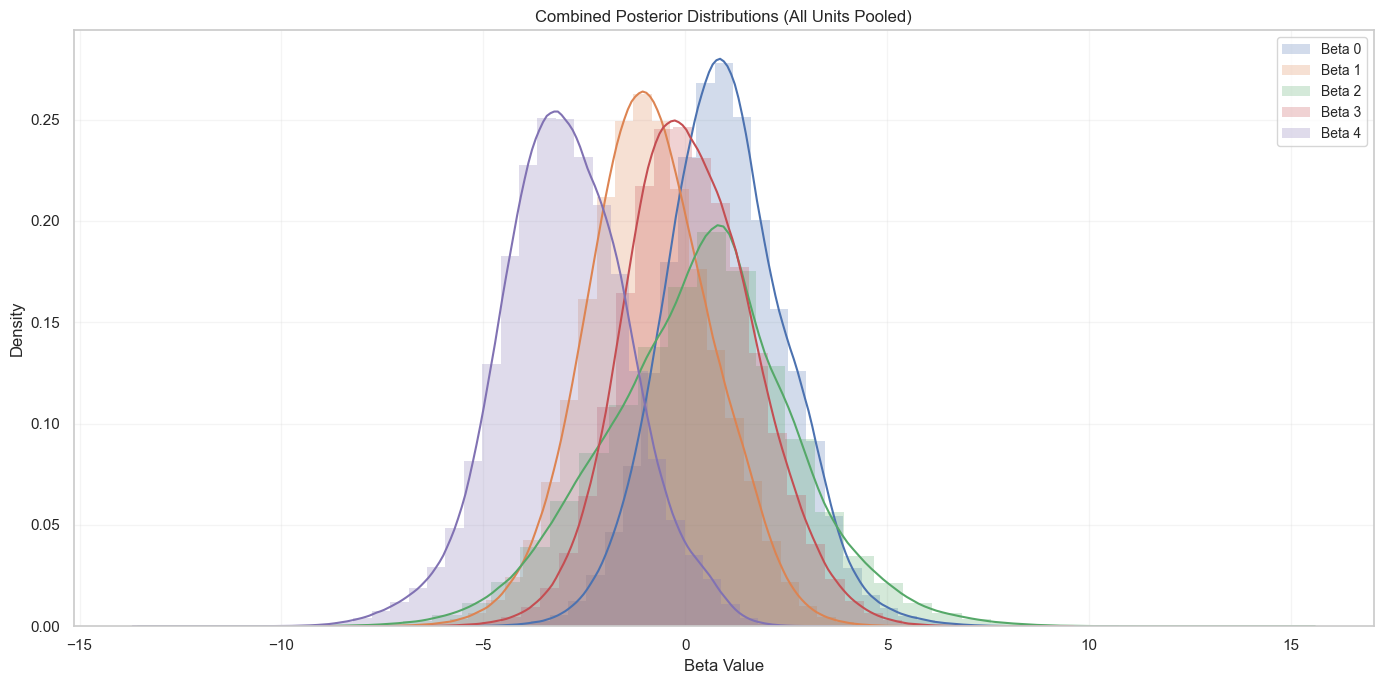

In [17]:
# ==========================================================
# COMBINED POSTERIOR DISTRIBUTIONS (Pooled Across All Units)
# ==========================================================

# All betas combined in one plot
print("\nAll Beta Indices (Pooled Across Units)")
def plot_all_betas_combined_hist_kde(samples_dict, beta_indices=None, bins=40):
    """
    Pool all beta samples across chains, draws, and units for each parameter.
    """
    if beta_indices is None:
        beta_indices = range(samples_dict["beta_i"].shape[3])
    
    beta = samples_dict["beta_i"]  # (chains, draws, units, betas)
    
    plt.figure(figsize=(14, 7))
    for b in beta_indices:
        arr = beta[..., b].reshape(-1)  # Flatten everything
        sns.histplot(arr, bins=bins, kde=True, stat="density",
                    alpha=0.25, linewidth=0, label=f"Beta {b}")
    
    plt.title("Combined Posterior Distributions (All Units Pooled)")
    plt.xlabel("Beta Value")
    plt.ylabel("Density")
    plt.grid(True, alpha=0.2)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

plot_all_betas_combined_hist_kde(samples)